# 2d Diffusion problem

**Python for HPC course**

Sebastian Ohlmann, Klaus Reuter

Max Planck Computing and Data Facility, Garching

## Example: Diffusion Equation

* toy problem: (constant) diffusion on a 2d periodic grid $u_t = \alpha \Delta u$
* finite difference Laplacian operator, 5-point stencil, explicit time stepping
* formula for time update of $u$ at position $x_i,y_j$ from time $t_n$ to $t_{n+1}$:

$$ u_{i,j}^{(n+1)} = u_{i,j}^{(n)} + \frac{\alpha \Delta t}{\Delta x^2} \left( 
u_{i-1,j}^{(n)}
+u_{i+1,j}^{(n)}
+u_{i,j-1}^{(n)}
+u_{i,j+1}^{(n)}
-4u_{i,j}^{(n)}
\right) $$

* 5pt stencil on a regular grid
![5pt Stencil](fig/stencil_5pt.svg)

## Example: Diffusion Equation

### compare various approaches
* naive Python implementation
* SciPy's Laplacian
* several NumPy variants
* Cython
* Numba
* Fortran implementation
* ... *plus* thread parallelization

## Initial condition, evolved solution
![matplotlib diffusion plot](./fig/diffusion_plot.png)

In [1]:
import os
for VAR in ["OMP_NUM_THREADS", "NUMBA_NUM_THREADS"]:
    if VAR not in os.environ:
        os.environ[VAR]="2"
    print("{}={}".format(VAR, os.environ[VAR]))
import numpy as np

OMP_NUM_THREADS=2
NUMBA_NUM_THREADS=2


In [2]:
%matplotlib inline

## Infrastructure code: parameters, init(), main_loop()

In [3]:
# parameters (global, for convenience)
n_iterations = 10
n_points = 128
dt = 0.12
D = 1.2

In [4]:
def init(val=0.5):
    """Set up a 2d NumPy array with some local square initial value pattern."""
    grid = np.zeros([n_points+2, n_points+2])
    # set a square patch near the corner to val > 0
    block_lo = int(n_points * .01)
    block_hi = int(n_points * .5)
    grid[block_lo:block_hi, block_lo:block_hi] = val
    return grid

In [5]:
def main_loop(evolve_func, grid):
    """Main loop function, calling evolve_func on grid."""
    grid_tmp = np.empty_like(grid)
    for i in range(1, n_iterations+1):
        evolve_func(grid, grid_tmp, n_points, dt, D)
        # swap references (do not copy data)
        grid_swap = grid
        grid = grid_tmp
        grid_tmp = grid_swap
    return grid

## A naive pure Python implementation

In [6]:
def apply_periodic_bc_python(grid, n_points):
    """Explicitly apply periodic boundary conditions, via Python loops."""
    for j in range(n_points + 2):
        grid[ 0, j] = grid[-2, j]
        grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i,-1] = grid[ i, 1]
        grid[ i, 0] = grid[ i,-2]

In [7]:
def evolve_python(grid, grid_tmp, n_points, dt, D):
    apply_periodic_bc_python(grid, n_points)
    for i in range(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * \
                (grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1] - 4.0 * grid[i, j])

In [8]:
%%time
grid = init()
solution_python = main_loop(evolve_python, grid)
# note the very small problem size at this point

CPU times: user 288 ms, sys: 422 µs, total: 289 ms
Wall time: 288 ms


## SciPy's Laplacian operator

In [9]:
from scipy.ndimage.filters import laplace as scipy_laplacian

def evolve_scipy(grid, grid_tmp, n_points, dt, D):
    """Time step based on the SciPy Laplacian."""
    grid_tmp[:] = grid + dt * D * scipy_laplacian(grid, mode='wrap')

In [10]:
%%time
grid = init()
solution_scipy = main_loop(evolve_scipy, grid)

CPU times: user 3.46 ms, sys: 0 ns, total: 3.46 ms
Wall time: 2.8 ms


In [11]:
# increase the problem size for the experiments below, not considering plain Python anymore
n_iterations = 1000
n_points = 1024
# expected scaling of run time: ~ n_iterations * n_points**2

In [12]:
%%time
grid = init()

CPU times: user 2.12 ms, sys: 181 µs, total: 2.3 ms
Wall time: 1.98 ms


In [13]:
%%time
grid = init()
solution_scipy = main_loop(evolve_scipy, grid)

CPU times: user 13 s, sys: 4.7 s, total: 17.7 s
Wall time: 17.7 s


### A look at the result

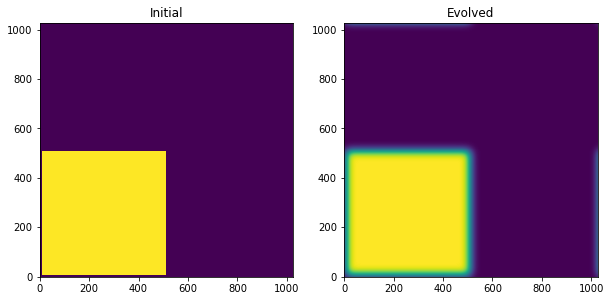

In [14]:
import matplotlib.pyplot as plt

def plot_grids(initial_grid, evolved_grid):
    f = plt.figure(figsize=(10,5))
    plt.subplot(121)
    plt.pcolormesh(initial_grid.T)
    plt.axis('image')
    plt.title('Initial')
    plt.subplot(122)
    plt.pcolormesh(evolved_grid.T)
    plt.axis('image')
    l = plt.title('Evolved')

plot_grids(init(), solution_scipy)

## NumPy experiments

### Laplacian implementation using NumPy's roll function
* roll() shifts an array by an offset along an axis
* elements that roll beyond the array limits enter back in from the other side

In [15]:
def laplacian_np_roll(grid):
    """Laplacian implementation based on the NumPy roll functionality."""
    return np.roll(grid, +1, 0) + np.roll(grid, -1, 0) \
         + np.roll(grid, +1, 1) + np.roll(grid, -1, 1) \
         - 4 * grid

def evolve_np_roll(grid, grid_tmp, n_points, dt, D):
    """Time step based on the NumPy-roll-Laplacian."""
    grid_tmp[:] = grid + dt * D * laplacian_np_roll(grid)

In [16]:
%%time
grid = init()
solution_roll = main_loop(evolve_np_roll, grid)

CPU times: user 11.2 s, sys: 13.2 ms, total: 11.2 s
Wall time: 11.2 s


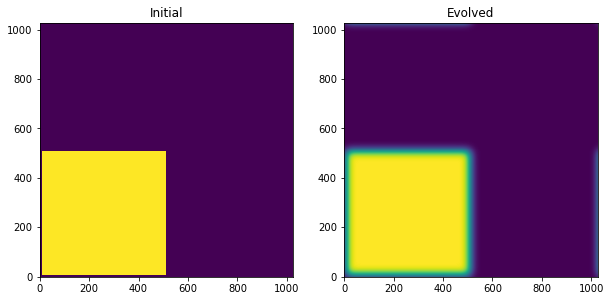

In [17]:
plot_grids(init(), solution_roll)

In [18]:
# a more memory-efficient implementation
def evolve_np_inplace_roll(grid, grid_tmp, n_points, dt, D):
    # time step
    grid_tmp[:] = -4.0 * grid
    grid_tmp += np.roll(grid, +1, 0)
    grid_tmp += np.roll(grid, -1, 0)
    grid_tmp += np.roll(grid, +1, 1)
    grid_tmp += np.roll(grid, -1, 1)
    grid_tmp *= dt * D
    grid_tmp += grid

In [19]:
%%time
grid = init()
solution_roll = main_loop(evolve_np_inplace_roll, grid)

CPU times: user 11.1 s, sys: 7.7 ms, total: 11.1 s
Wall time: 11.1 s


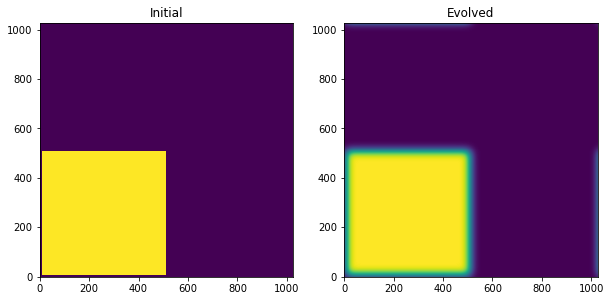

In [20]:
plot_grids(init(), solution_roll)

### NumPy slicing notation

In [21]:
# without np.roll() we need to handle the periodicity explicitly
def apply_periodic_bc(grid, n_points):
    """Explicitly apply periodic boundary conditions, using NumPy ranges."""
    grid[ 0, :] = grid[-2, :]
    grid[-1, :] = grid[ 1, :]
    grid[ :,-1] = grid[ :, 1]
    grid[ :, 0] = grid[ :,-2]

In [22]:
%%time
apply_periodic_bc_python(grid, n_points)

CPU times: user 982 µs, sys: 121 µs, total: 1.1 ms
Wall time: 1.11 ms


In [23]:
%%time
apply_periodic_bc(grid, n_points)

CPU times: user 269 µs, sys: 34 µs, total: 303 µs
Wall time: 210 µs


In [24]:
def evolve_np_slicing(grid, grid_tmp, n_points, dt, D):
    """Time step based on an explicitly coded Laplacian using array slicing."""
    apply_periodic_bc(grid, n_points)
    grid_tmp[1:-1, 1:-1] = grid[1:-1, 1:-1] \
                     + dt * D * (   grid[0:-2, 1:-1] + grid[2:  , 1:-1] \
                                  + grid[1:-1, 0:-2] + grid[1:-1, 2:  ] \
                                  - 4.0 * grid[1:-1, 1:-1] )

In [25]:
%%time
grid = init()
solution_np_slicing = main_loop(evolve_np_slicing, grid)

CPU times: user 9.61 s, sys: 0 ns, total: 9.61 s
Wall time: 9.61 s


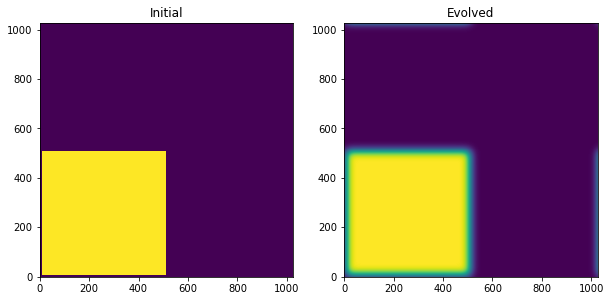

In [26]:
plot_grids(init(), solution_np_slicing)

In [27]:
def evolve_np_inplace_slicing(grid, grid_tmp, n_points, dt, D):
    apply_periodic_bc(grid, n_points)
    grid_tmp[1:-1, 1:-1] = -4.0 * grid[1:-1, 1:-1]
    grid_tmp[1:-1, 1:-1] += grid[0:-2, 1:-1]
    grid_tmp[1:-1, 1:-1] += grid[2:  , 1:-1]
    grid_tmp[1:-1, 1:-1] += grid[1:-1, 0:-2]
    grid_tmp[1:-1, 1:-1] += grid[1:-1, 2:  ]
    grid_tmp[1:-1, 1:-1] *= dt * D
    grid_tmp[1:-1, 1:-1] += grid[1:-1, 1:-1]

In [28]:
%%time
grid = init()
solution_np_slicing = main_loop(evolve_np_inplace_slicing, grid)

CPU times: user 15.4 s, sys: 0 ns, total: 15.4 s
Wall time: 15.4 s


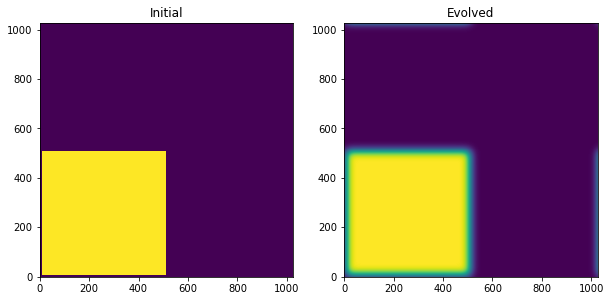

In [29]:
plot_grids(init(), solution_np_slicing)

## Introducing compiled code using Cython
* goal: push as much code as possible into the compiled layer

### first attempt: naive compilation
* let's start with the Python loop-based implementation

In [30]:
%load_ext Cython

In [31]:
%%cython -c=-O3 -c=-march=native -c=-ffast-math

def apply_periodic_bc_cython(grid, n_points):
    for j in range(n_points + 2):
        grid[ 0, j] = grid[-2, j]
        grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i,-1] = grid[ i, 1]
        grid[ i, 0] = grid[ i,-2]

def evolve_cython(grid, grid_tmp, n_points, dt, D):
    apply_periodic_bc_cython(grid, n_points)
    for i in range(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

### Naive compilation
* Simply applying the Cython compiler to plain Python code does not speed it up!
* We need to guide Cython by adding type declarations to generate efficient code.

In [32]:
%%time
grid = init()
#main_loop(evolve_cython, grid)

# measured wall clock time during lunch break: 25 minutes!!!

CPU times: user 1.46 ms, sys: 108 µs, total: 1.57 ms
Wall time: 844 µs


## Cython 'annotate' optimization guidance
* Cython is able to create a colorized output of the source, where interaction with Python code and other inefficiencies are highlighted
* out goal is to get rid of any yellow in the output
* invocation from the command line, generates HTML file  
  `cythonize --annotate source.pyx`
* invocation from Jupyter, see below

In [33]:
%%cython -c=-O3 -c=-march=native -c=-ffast-math --annotate

def apply_periodic_bc_cython(grid, n_points):
    for j in range(n_points + 2):
        grid[ 0, j] = grid[-2, j]
        grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i,-1] = grid[ i, 1]
        grid[ i, 0] = grid[ i,-2]

def evolve_cython(grid, grid_tmp, n_points, dt, D):
    apply_periodic_bc_cython(grid, n_points)
    for i in range(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

### Cython, step 1: Adding type information
* to enable Cython to create efficient C code, we need to add data type declarations
    * function parameters (e.g. declare parameters as `np.ndarray`, `int`, `double`)
    * function body (e.g. declare variables as `cdef int`)
* function declarations
    * `def`: Python function, takes Python objects as parameters and returns Python objects
    * `cdef`: C function, not callable from Python, takes C values or Python objects as parameters and returns C values or Python objects
    * `cpdef`: hybrid C and Python function
* note that at this point we break Python source code compatibility

In [34]:
%%cython -c=-O3 -c=-march=native -c=-ffast-math --annotate

import numpy as np
cimport numpy as np

cdef apply_periodic_bc_cython(np.ndarray grid, int n_points):
    cdef int i, j
    for j in range(n_points + 2):
        grid[ 0, j] = grid[-2, j]
        grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i,-1] = grid[ i, 1]
        grid[ i, 0] = grid[ i,-2]

def evolve_cython(np.ndarray grid, np.ndarray grid_tmp, int n_points, double dt, double D):
    cdef int i, j
    apply_periodic_bc_cython(grid, n_points)
    for i in range(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

### Cython, step 2: Efficient indexing
* until now, each array access `[]` implies Python interaction
* to enable efficient indexing at C speed, we need to specify for NumPy arrays
    * dimensionality
    * native datatype
    * $\to$ add `np.ndarray[np.float64_t, ndim=2]` to our code

In [35]:
%%cython -c=-O3 -c=-march=native -c=-ffast-math --annotate

import numpy as np
cimport numpy as np

cdef apply_periodic_bc_cython(np.ndarray[np.float64_t, ndim=2] grid, int n_points):
    cdef int i, j
    for j in range(n_points + 2):
        grid[ 0, j] = grid[-2, j]
        grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i,-1] = grid[ i, 1]
        grid[ i, 0] = grid[ i,-2]

def evolve_cython(np.ndarray[np.float64_t, ndim=2] grid, np.ndarray[np.float64_t, ndim=2] grid_tmp,
                  int n_points, double dt, double D):
    cdef int i, j
    apply_periodic_bc_cython(grid, n_points)
    for i in range(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

### Cython, step 3: Tuning indexing further
Until now, each indexing `[]` operation is capable of
* bounds checking
* handling of negative indices

We may disable these features via decorators to gain additional speed. However, we need to remove the negative indices from the code at this point.

In [36]:
%%cython -c=-O3 -c=-march=native -c=-ffast-math --annotate

import numpy as np
cimport numpy as np
cimport cython

@cython.boundscheck(False) # turn off bounds-checking
@cython.wraparound(False)  # turn off negative index wrapping
cpdef apply_periodic_bc_cython(np.ndarray[np.float64_t, ndim=2] grid, int n_points):
    cdef int i, j
    for j in range(n_points + 2):
        grid[         0, j] = grid[n_points, j]  # grid[ 0, j] = grid[-2, j]
        grid[n_points-1, j] = grid[       1, j]  # grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i, n_points-1] = grid[ i,          1]  # grid[ i,-1] = grid[ i, 1]
        grid[ i,          0] = grid[ i, n_points-2]  # grid[ i, 0] = grid[ i,-2]

@cython.boundscheck(False) # turn off bounds-checking
@cython.wraparound(False)  # turn off negative index wrapping
def evolve_cython(np.ndarray[np.float64_t, ndim=2] grid, np.ndarray[np.float64_t, ndim=2] grid_tmp,
                  int n_points, double dt, double D):
    cdef int i, j
    apply_periodic_bc_cython(grid, n_points)
    for i in range(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

In [37]:
%%time
grid = init()
solution_cython = main_loop(evolve_cython, grid)

CPU times: user 1.87 s, sys: 62 µs, total: 1.87 s
Wall time: 1.87 s


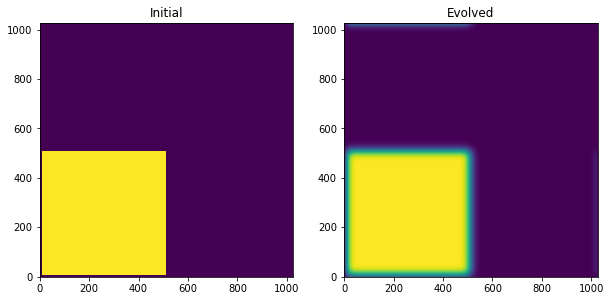

In [38]:
plot_grids(init(), solution_cython)

### Reminder: Be aware of the memory ordering!
* Memory layout of numpy arrays: row-major $\to$ last index changes fastest
* Different loop ordering does not access memory sequentially $\to$ much slower!

In [39]:
%%cython -c=-O3 -c=-march=native -c=-ffast-math

import numpy as np
cimport numpy as np
cimport cython

@cython.boundscheck(False) # turn off bounds-checking
@cython.wraparound(False)  # turn off negative index wrapping
cpdef apply_periodic_bc_cython(np.ndarray[np.float64_t, ndim=2] grid, int n_points):
    cdef int i, j
    for j in range(n_points + 2):
        grid[         0, j] = grid[n_points, j]  # grid[ 0, j] = grid[-2, j]
        grid[n_points-1, j] = grid[       1, j]  # grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i, n_points-1] = grid[ i,          1]  # grid[ i,-1] = grid[ i, 1]
        grid[ i,          0] = grid[ i, n_points-2]  # grid[ i, 0] = grid[ i,-2]

@cython.boundscheck(False) # turn off bounds-checking
@cython.wraparound(False)  # turn off negative index wrapping
def evolve_cython_wrong_loop_order(np.ndarray[np.float64_t, ndim=2] grid,
                                   np.ndarray[np.float64_t, ndim=2] grid_tmp,
                                   int n_points, double dt, double D):
    cdef int i, j
    apply_periodic_bc_cython(grid, n_points)
    for j in range(1, n_points+1):
        for i in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

In [40]:
%%time
grid = init()
solution_cython_wrong_order = main_loop(evolve_cython_wrong_loop_order, grid)

CPU times: user 3.31 s, sys: 0 ns, total: 3.31 s
Wall time: 3.31 s


$\to$ always use the right loop ordering: **innermost loop for last index**

## Comparison to Fortran

In [7]:
! cd fortran && make clean diff.exe

rm -f diff_mpi.exe diff.exe *.o *.mod
gfortran -O3 -march=native -fopt-info-vec -fopenmp -fno-strict-aliasing -o diff.exe diff.F90
diff.F90:30:0: note: loop vectorized
diff.F90:30:0: note: loop versioned for vectorization because of possible aliasing
diff.F90:19:0: note: loop vectorized
diff.F90:19:0: note: loop versioned for vectorization because of possible aliasing
diff.F90:18:0: note: loop vectorized
diff.F90:18:0: note: loop versioned for vectorization because of possible aliasing
diff.F90:10:0: note: loop vectorized
diff.F90:56:0: note: basic block vectorized
diff.F90:10:0: note: basic block vectorized
diff.F90:68:0: note: basic block vectorized
diff.F90:38:0: note: basic block vectorized
diff.F90:19:0: note: loop vectorized
diff.F90:19:0: note: loop versioned for vectorization because of possible aliasing
diff.F90:18:0: note: loop vectorized
diff.F90:18:0: note: loop versioned for vectorization because of possible aliasing
diff.F90:10:0: note: loop vectorized


In [8]:
! cd fortran && /usr/bin/env OMP_NUM_THREADS=1 ./diff.exe

          10 %
          20 %
          30 %
          40 %
          50 %
          60 %
          70 %
          80 %
          90 %
         100 %
 main loop time =   1.3017804729752243     


## Cython summary
* starting from a naive Python code, we generated efficient compiled code rather easily
* speedup Cython vs. Python: ~700
* speedup Fortran vs. Cython: ~1.5
* key steps: add data types, enable C indexing, "get rid of yellow annotations"
* disadvantage: we lost Python code compatibility

## How to gain even more?

* write stencil kernel in C or Fortran, focus on
    * vectorization
    * parallelization
    * cache-aware programming
* Numba (see below)

## Bonus: OpenMP parallelization with Cython
* Cython supports (a subset of) OpenMP
* control the number of threads via
    * `OMP_NUM_THREADS` environment variable, or
    * passing `num_threads` to the `parallel()` object
* Be careful: "Thread-locality and reductions are automatically inferred for variables."  
  http://cython.readthedocs.io/en/latest/src/userguide/parallelism.html
* Complex OpenMP-parallel patterns should probably better be implemented in native C or Fortran.

In [94]:
%%cython -c=-O3 -c=-march=native -c=-ffast-math -c=-fopenmp

import numpy as np
cimport numpy as np
cimport cython
from cython.parallel import parallel, prange

@cython.boundscheck(False) # turn off bounds-checking
@cython.wraparound(False)  # turn off negative index wrapping
cpdef apply_periodic_bc_cython(np.ndarray[np.float64_t, ndim=2] grid, int n_points):
    cdef int i, j
    for j in range(n_points + 2):
        grid[         0, j] = grid[n_points, j]  # grid[ 0, j] = grid[-2, j]
        grid[n_points-1, j] = grid[       1, j]  # grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i, n_points-1] = grid[ i,          1]  # grid[ i,-1] = grid[ i, 1]
        grid[ i,          0] = grid[ i, n_points-2]  # grid[ i, 0] = grid[ i,-2]

@cython.boundscheck(False) # turn off bounds-checking
@cython.wraparound(False)  # turn off negative index wrapping
def evolve_cython_parallel(np.ndarray[np.float64_t, ndim=2] grid, np.ndarray[np.float64_t, ndim=2] grid_tmp,
                           int n_points, double dt, double D):
    cdef int i, j
    apply_periodic_bc_cython(grid, n_points)
    with nogil, parallel():
        for i in prange(1, n_points+1):
            for j in range(1, n_points+1):
                # stencil formula
                grid_tmp[i, j] = grid[i, j] + dt * D * (
                    grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                    - 4.0 * grid[i, j])

In [43]:
%%time
grid = init()
solution_cython_parallel = main_loop(evolve_cython_parallel, grid)

CPU times: user 2.23 s, sys: 0 ns, total: 2.23 s
Wall time: 1.12 s


In [6]:
! cd fortran && cat diff_par.nml && /usr/bin/env OMP_NUM_THREADS=2 ./diff.exe

&diff
  n_iterations = 1000
  np = 1024
  dt = 0.12
  D = 1.2
/
          10 %
          20 %
          30 %
          40 %
          50 %
          60 %
          70 %
          80 %
          90 %
         100 %
 main loop time =   1.1403847299516201     


## Numba
* Numba is a just-in-time compiler based on LLVM
* usage via the decorator `@jit`

### Naive approach: jit'ting the plain Python code

In [80]:
from numba import jit, prange

In [81]:
@jit(nopython=True, fastmath=True)
def apply_periodic_bc_python_numba(grid, n_points):
    """Explicitly apply periodic boundary conditions, via Python loops."""
    for j in range(n_points + 2):
        grid[ 0, j] = grid[-2, j]
        grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i,-1] = grid[ i, 1]
        grid[ i, 0] = grid[ i,-2]

In [82]:
@jit(nopython=True, fastmath=True)  # parallel=True turns out to slow down the code a bit
def evolve_python_numba(grid, grid_tmp, n_points, dt, D):
    apply_periodic_bc_python_numba(grid, n_points)
    for i in range(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

In [83]:
grid = init()
solution_numba = main_loop(evolve_python_numba, grid)

In [84]:
%%time
grid = init()
solution_numba = main_loop(evolve_python_numba, grid)

CPU times: user 1.06 s, sys: 114 µs, total: 1.06 s
Wall time: 1.05 s


In [71]:
@jit(nopython=True, fastmath=True, parallel=True)
def evolve_python_numba_parallel(grid, grid_tmp, n_points, dt, D):
    apply_periodic_bc_python_numba(grid, n_points)
    for i in prange(1, n_points+1):
        for j in range(1, n_points+1):
            # stencil formula
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1]
                - 4.0 * grid[i, j])

In [85]:
grid = init()
solution_numba = main_loop(evolve_python_numba_parallel, grid)

In [86]:
%%time
grid = init()
solution_numba = main_loop(evolve_python_numba_parallel, grid)

CPU times: user 2.07 s, sys: 62.3 ms, total: 2.13 s
Wall time: 1.02 s


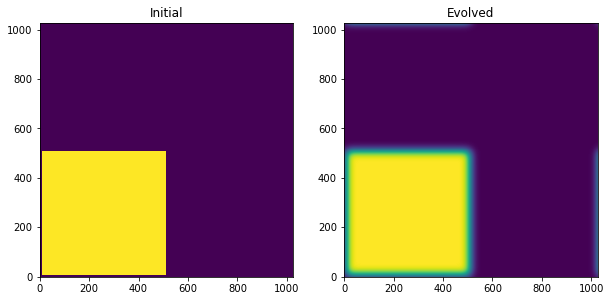

In [73]:
plot_grids(init(), solution_numba)

### Applying @jit to NumPy expressions
* Numba is aware of a (growing) number of NumPy functions
    * not aware of `roll()`
    * not aware of the SciPy Laplacian
    * but well aware of NumPy array notation
* Numba is able to parallelize some NumPy expressions

In [87]:
@jit(nopython=True, fastmath=True, parallel=True)
def apply_periodic_bc_numba(grid, n_points):
    """Explicitly apply periodic boundary conditions, using NumPy ranges."""
    grid[ 0, :] = grid[-2, :]
    grid[-1, :] = grid[ 1, :]
    grid[ :,-1] = grid[ :, 1]
    grid[ :, 0] = grid[ :,-2]

In [88]:
@jit(nopython=True, fastmath=True)
def evolve_np_slicing_numba(grid, grid_tmp, n_points, dt, D):
    """Time step based on an explicitly coded Laplacian using array slicing."""
    apply_periodic_bc_numba(grid, n_points)
    grid_tmp[1:-1, 1:-1] = grid[1:-1, 1:-1] \
                     + dt * D * (   grid[0:-2, 1:-1] + grid[2:  , 1:-1] \
                                  + grid[1:-1, 0:-2] + grid[1:-1, 2:  ] \
                                  - 4.0 * grid[1:-1, 1:-1] )

In [89]:
grid = init()
solution_numba = main_loop(evolve_np_slicing_numba, grid)

In [90]:
%%time
grid = init()
solution_numba = main_loop(evolve_np_slicing_numba, grid)

CPU times: user 6.38 s, sys: 69.7 ms, total: 6.45 s
Wall time: 6.15 s


In [91]:
@jit(nopython=True, fastmath=True, parallel=True)
def evolve_np_slicing_numba_parallel(grid, grid_tmp, n_points, dt, D):
    """Time step based on an explicitly coded Laplacian using array slicing."""
    apply_periodic_bc_numba(grid, n_points)
    grid_tmp[1:-1, 1:-1] = grid[1:-1, 1:-1] \
                     + dt * D * (   grid[0:-2, 1:-1] + grid[2:  , 1:-1] \
                                  + grid[1:-1, 0:-2] + grid[1:-1, 2:  ] \
                                  - 4.0 * grid[1:-1, 1:-1] )

In [92]:
grid = init()
solution_numba = main_loop(evolve_np_slicing_numba_parallel, grid)

In [93]:
%%time
grid = init()
solution_numba = main_loop(evolve_np_slicing_numba_parallel, grid)

CPU times: user 2.87 s, sys: 154 ms, total: 3.03 s
Wall time: 1.37 s


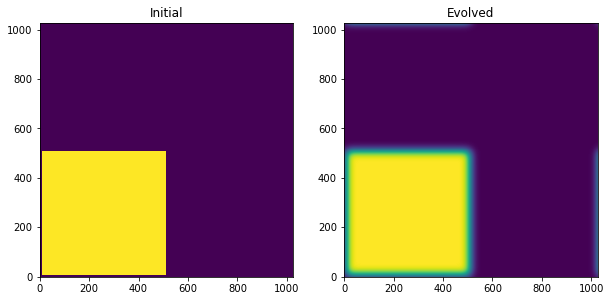

In [79]:
plot_grids(init(), solution_numba)

## Numba summary
* Numba may accelerate your code significantly
* Numba works very well with naive Python loops
* Numba speeds up certain NumPy array expressions, may even parallelize them
* Advantage: Python code compatibility is preserved
* Disadvantage: Debugging rather complex in case @jit does not work as expected

### Thank you very much!

### Questions?